## Esercitazione 9 - 23  Aprile 2026


## Condizionamento del problema della soluzione di un sistema lineare

# Esercizio 1
- Costruire la matrice di Vandermonde A, generata dal vettore x=[1.0,2.0,...,6.0] utilizzando la funzione np.vander(x, increasing=True) di numpy. 
- Calcolarne l'indice di condizionamento in norma infinito senza utilizzare la funzione cond di numpy.linalg e poi confrontarne il valore con quello ottenuto utilizzando la funzione.
- Considerare il sistema lineare Ax=b  con matrice dei coefficienti A e termine noto costruito in maniera tale che la soluzione esatta sia il vettore x=[1,1,1,1,1,1] (ogni sua componente è 1) e risolverlo usando il metodo solve del modulo linalg di Scipy.
- perturbare il vettore dei termini noti della quantità
- 
$$
\delta b = 0.025 \, \ast \,
\left [
\begin{array}{c}
1\\
0\\
0\\
0
\end{array}
\right ]
$$
- Risolvere il sistema con termine noto pertubato $b + \delta b$ ((usando il metodo solve del modulo linalg di Scipy).
- Calcolare l'errore relativo sul termine noto e l'errore relativo sulla soluzione. Cosa si può concludere?

N.B. per il calcolo dell'inversa della matrice di A usare la funzione di numpy.linalg.inv(A).


In [1]:
import numpy as np
import numpy.linalg as npl
import scipy.linalg as spl

In [2]:
x = np.arange(1.0, 7.0)
A = np.vander(x, increasing=True)
n = A.shape[0]
print(A)
my_cond = np.linalg.norm(A, np.inf) * np.linalg.norm(np.linalg.inv(A), np.inf)
print("Indice di condizionamento ", my_cond)

condp = np.linalg.cond(A, np.inf)
print("Indice di condizionamento ", condp)

[[1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00 1.000e+00]
 [1.000e+00 2.000e+00 4.000e+00 8.000e+00 1.600e+01 3.200e+01]
 [1.000e+00 3.000e+00 9.000e+00 2.700e+01 8.100e+01 2.430e+02]
 [1.000e+00 4.000e+00 1.600e+01 6.400e+01 2.560e+02 1.024e+03]
 [1.000e+00 5.000e+00 2.500e+01 1.250e+02 6.250e+02 3.125e+03]
 [1.000e+00 6.000e+00 3.600e+01 2.160e+02 1.296e+03 7.776e+03]]
Indice di condizionamento  1204321.066666817
Indice di condizionamento  1204321.066666817


In [3]:
b = np.sum(A, axis=1).reshape(n, 1)
print(b)

[[6.000e+00]
 [6.300e+01]
 [3.640e+02]
 [1.365e+03]
 [3.906e+03]
 [9.331e+03]]


In [4]:
x_esatta = np.ones((n,1))

In [5]:
bpert = b.copy()
bpert[0] = bpert[0] + 0.025
xpert = spl.solve(A, bpert)
print(xpert)
errore_relativo_dati = np.linalg.norm(bpert - b, np.inf) / np.linalg.norm(b, np.inf)

errore_relativo_soluzione = np.linalg.norm(xpert - x_esatta, np.inf) / np.linalg.norm(x_esatta, np.inf)
print("errore dati ", errore_relativo_dati, "Percentuale ", errore_relativo_dati * 100)
print("errore soluzione ", errore_relativo_soluzione, "Percentuale ", errore_relativo_soluzione * 100)

[[1.15      ]
 [0.7825    ]
 [1.12083333]
 [0.96770833]
 [1.00416667]
 [0.99979167]]
errore dati  2.679241238881187e-06 Percentuale  0.0002679241238881187
errore soluzione  0.21749999998610292 Percentuale  21.749999998610292


## Esercizio 2
Assegnato il sistema lineare $Ax = b$, con
$$
A =
\left [
\begin{array}{ccc}
6 & 63 & 662.2\\
63 & 662.2 & 6967.8\\
662.2 & 6967.8 & 73393.5664
\end{array}
\right ], \qquad
b =
\left [
\begin{array}{c}
1.1\\
2.33\\
1.7
\end{array}
\right ]
$$
- trovare il vettore soluzione $x$ (usando il metodo solve del modulo linalg di Scipy);
- perturbare la matrice dei coefficienti della quantità
$$
\delta A =
0.01 \, \ast \,
\left [ \begin{array}{ccc}
1 & 0 & 0\\
0 & 0 & 0\\
0 & 0 & 0
\end{array}
\right ]
$$
quindi calcolare l'errore relativo sulla soluzione e confrontarlo con la
perturbazione relativa sui dati di ingresso. Cosa si osserva?

## Esercizio 3
 
Assegnato il sistema lineare $Ax = b$, con $A$ matrice di Hilbert di ordine
$4$ e $b = [1, 1, 1, 1]^T$,
 - trovare il vettore soluzione $x$ (usando il metodo solve del modulo linalg di Scipy);
 -  perturbare il vettore dei termini noti della quantità
$$
\delta b = 0.01 \, \ast \,
\left [
\begin{array}{c}
1\\
-1\\
1\\
-1
\end{array}
\right ]
$$
quindi calcolare la soluzione del sistema $A x_p= b_p$ con termine noto $b_p=b+ \delta b$.
Calcolare l'errore relativo sulla soluzione e confrontarlo con la perturbazione relativa sui dati di ingresso. Cosa si osserva?

Nota: per la costruzione della matrice di Hilbert usare la funzione hilbert(n) del modulo scipy.linalg
(scipy.linalg.hilbert(n))  dove bisogna specificare l'ordine n della matrice.

In [6]:
A = spl.hilbert(4)
n = A.shape[0]
print(A)

condp = np.linalg.cond(A, np.inf)
print("Indice di condizionamento ", condp)

[[1.         0.5        0.33333333 0.25      ]
 [0.5        0.33333333 0.25       0.2       ]
 [0.33333333 0.25       0.2        0.16666667]
 [0.25       0.2        0.16666667 0.14285714]]
Indice di condizionamento  28374.999999997388


In [7]:
b = np.array([1,1,1,1]).reshape(n, 1)
print(b)

[[1]
 [1]
 [1]
 [1]]


In [8]:
x_esatta = spl.solve(A, b)
print(x_esatta)

[[  -4.]
 [  60.]
 [-180.]
 [ 140.]]


In [9]:
bpert = b.copy()
bpert[0] = bpert[0] * 0.01
bpert[1] = -bpert[1] * 0.01
bpert[2] = bpert[2] * 0.01
bpert[3] = -bpert[3] * 0.01

xpert = spl.solve(A, bpert)
print(xpert)
errore_relativo_dati = np.linalg.norm(bpert - b, np.inf) / np.linalg.norm(b, np.inf)

errore_relativo_soluzione = np.linalg.norm(xpert - x_esatta, np.inf) / np.linalg.norm(x_esatta, np.inf)
print("errore dati ", errore_relativo_dati, "Percentuale ", errore_relativo_dati * 100)
print("errore soluzione ", errore_relativo_soluzione, "Percentuale ", errore_relativo_soluzione * 100)

[[0.]
 [0.]
 [0.]
 [0.]]
errore dati  1.0 Percentuale  100.0
errore soluzione  1.0 Percentuale  100.0


## Metodi diretti per la soluzione numerica di un sistema lineare

## Nota 1.
La funzione *scipy.linalg.lu(A)*  , presa in input una matrice A a rango massimo, restituisce in output le matrici $P^T$,L,U,  della fattorizzazione di LU della matrice A in maniera tale che PA=LU (restituisce la matrice di permutazione trasposta)

In [10]:
import numpy as np
import scipy as sp
from scipy.linalg import lu
A=np.array([[2,1],[3,4]])
PT,L,U=lu(A)  #Restituisce in output la trasposta della matrice di Permutazione
P=PT.copy()   #P è la matrice di permutazione
print("A=",A)
print("L=",L)
print("U=",U)
print("P=",P)
#LU è la fattorizzazione di P*A (terorema 2)
A1=P@A # equivale al prodotto matrice x matrice np.dot(P,A)
A1Fatt=L@U # equivale a np.dot(L,U)
print("Matrice P*A \n", A1)
print("Matrice ottenuta moltipicando Le ed U \n",A1Fatt)


A= [[2 1]
 [3 4]]
L= [[1.         0.        ]
 [0.66666667 1.        ]]
U= [[ 3.          4.        ]
 [ 0.         -1.66666667]]
P= [[0. 1.]
 [1. 0.]]
Matrice P*A 
 [[3. 4.]
 [2. 1.]]
Matrice ottenuta moltipicando Le ed U 
 [[3. 4.]
 [2. 1.]]


## Nota 2
La funzione *scipy.linalg.cholesky(a, lower=True)*, presa in input una matrice simmetrica e definta positiva restituisce in output la matrice L triangolare inferiore tale che $A=L \cdot L^T$. Se la matrice in input non è definita positiva, restituisce un errore.

In [11]:
from scipy.linalg import cholesky
A=np.array([[2,1,3],[1,5,7],[3,7,12]])
print(A)

[[ 2  1  3]
 [ 1  5  7]
 [ 3  7 12]]


In [12]:
L=cholesky(A,lower=True)
print(L)
A1=L@L.T
print("A1=\n",A1)

[[1.41421356 0.         0.        ]
 [0.70710678 2.12132034 0.        ]
 [2.12132034 2.59272486 0.8819171 ]]
A1=
 [[ 2.  1.  3.]
 [ 1.  5.  7.]
 [ 3.  7. 12.]]


## Nota 3
La funzione *scipy.linalg.qr(a)*, presa in input una matrice A (nxn)  a rango massimo, restituisce in output le matrici Q (ortogonale di dimensione nxn) ed una matrice R (nxn) triangolare superiore tale che $A=Q \cdot R$

In [13]:
from scipy.linalg import qr
A=np.array([[2,1,3],[1,5,7],[3,7,12]])
Q,R=qr(A)
print("Q=",Q)
print("R=",R)
A1=Q@R
print(A1)

Q= [[-0.53452248  0.6882472  -0.49051147]
 [-0.26726124 -0.6882472  -0.67445327]
 [-0.80178373 -0.22941573  0.55182541]]
R= [[ -3.74165739  -7.48331477 -13.09580085]
 [  0.          -4.35889894  -5.50597761]
 [  0.           0.           0.42919754]]
[[ 2.  1.  3.]
 [ 1.  5.  7.]
 [ 3.  7. 12.]]


## Esercizio 4
- si implementi una function LUsolve(P,A,L,U,b) che risolve il sistema lineare Ax=b nel caso di fattorizzazione $PA = LU$ assegnata,
combinando i metodi di risoluzione in avanti ed all'indietro  implementati nel file SolveTriangular.py.
- si testi sulla matrice A = np.array([[2, 5, 8, 7], [5, 2, 2, 8], [7, 5, 6, 6], [5, 4, 4, 8]]) con termine noto b scelto in maniera tale che la soluzione esatta del sistema lineare sia il vettore formato da tutti 1.

In [14]:
import SolveTriangular as ST

In [15]:
def LUsolve(P, L, U, b):
    Pb = P@b
    y, flag = ST.Lsolve(L, Pb)
    if flag == 0:
        x, flag = ST.Usolve(U, y)
    else:
        return [], flag
    return x, flag

In [16]:
A4 = np.array([[2, 5, 8, 7], [5, 2, 2, 8], [7, 5, 6, 6], [5, 4, 4, 8]], dtype=float)
n4 = A4.shape[0]
b4 = np.sum(A4, axis=1).reshape(n4, 1)
P4T,L4,U4 = lu(A4)
P4 = P4T.T
x4, flag = LUsolve(P4, L4, U4, b4)
print(x4)

[[1.]
 [1.]
 [1.]
 [1.]]


## Esercizio 5
Si implementi una function *solve_nsis(A,B)* per il calcolo della soluzione di un generale sistema lineare $AX = B$, con $X, B$ matrici, che usi la fattorizzazione LU della matrice PA, per risolvere n sistemi lineari: aventi la stessa matrice dei coefficienti A e termine noto l'i-esima colonna della matrice B. 
Utilizzarla poi per il calcolo dell'inversa delle
matrici non singolari
$$
A=\left[
\begin{array}{ccc}
3 & 5 & 7\\
2 & 3 & 4\\
5 & 9 & 11
\end{array}
\right ], \qquad
A=\left[
\begin{array}{cccc}
1 & 2 & 3 & 4\\
2 & -4 & 6 & 8\\
-1 & -2 & -3 & -1\\
5 & 7 & 0 & 1
\end{array}
\right ],
$$
confrontando i risultati ottenuti con l'output
della funzione  *scipy.linalg.inv(A)*

## Esercizio 6
Sfruttando la fattorizzazione PA=LU  di una delle matrici del punto precedente, calcolarne il determinante.


## Esercizio 7
Per valori di $n = 10,..,30$, si consideri il sistema lineare $A_n x = b$ con
$A_n$ matrice di Hankel di ordine $n$ di elementi
$$
a^{(n)}_{i,n+k-i}
=
\left \{
\begin{array}{ll}
2^k & \hbox{se} \ k > 0,\\
2^{1/(2-k)} & \hbox{se} \ k \leq 0,
\end{array}
\right .
\qquad
i = 1, ..., n, \ \  k = i + 1-n, ..., i,
$$
e $b$ scelto in modo che risulti $x = [1, 1, ..., 1]^T$. Si risolva tale sistema
con il metodo di fattorizzazione LU della matrice PA
e il metodo di fattorizzazione QR (Q,R  =scipy.linalg.qr(A)).
Calcolare gli errori relativi $\| \delta x \|_2/\|x\|_2$ da cui sono affette
le soluzioni calcolate con i due metodi e produrre, al variare di $n$, un
grafico in scala logaritmica ( matplotlib.plyplot.loglog) degli errori relativi calcolati. Che cosa si
osserva?

NB: per il calcolo della matrice di Hankel utilizzare la function 

def Hankel(n):

    A=np.zeros((n,n),dtype=float)
    for i in range(0,n):
        for k in range(i+1-n,i+1):
            if k>0:
                A[i,n-1+k-i]=2.0**(k+1)
            else:
                A[i,n-1+k-i]=2.0**(1/(2-k-1))
    return A

In [17]:
def Hankel(n):

    A=np.zeros((n,n),dtype=float)
    for i in range(0,n):
        for k in range(i+1-n,i+1):
            if k>0:
                A[i,n-1+k-i]=2.0**(k+1)
            else:
                A[i,n-1+k-i]=2.0**(1/(2-k-1))
    return A

In [18]:
import matplotlib.pyplot as plt

In [19]:
indCond = []
err_rel_sol_lu = []
err_rel_sol_qr = []

Fattore cresciita U 1.0 Fattore cresciita R 0.8196603392870231
Fattore cresciita U 1.0 Fattore cresciita R 0.806148033264684
Fattore cresciita U 1.0 Fattore cresciita R 0.8279189540529773
Fattore cresciita U 1.0 Fattore cresciita R 0.8467113858916723
Fattore cresciita U 1.0 Fattore cresciita R 0.8631100557227005
Fattore cresciita U 1.0 Fattore cresciita R 0.8775562552222446
Fattore cresciita U 1.0 Fattore cresciita R 0.8903885080099155
Fattore cresciita U 1.0 Fattore cresciita R 0.9018705562667035
Fattore cresciita U 1.0 Fattore cresciita R 0.912210866706273
Fattore cresciita U 1.0 Fattore cresciita R 0.9215764181672272
Fattore cresciita U 1.0 Fattore cresciita R 0.9301025909614201
Fattore cresciita U 1.0 Fattore cresciita R 0.9379003650750047
Fattore cresciita U 1.0 Fattore cresciita R 0.9450616352939898
Fattore cresciita U 1.0 Fattore cresciita R 0.951663190313979
Fattore cresciita U 1.0 Fattore cresciita R 0.9577697307924763
Fattore cresciita U 1.0 Fattore cresciita R 0.963436186688

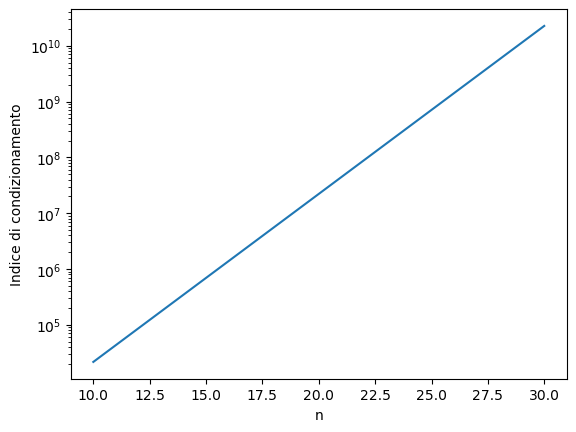

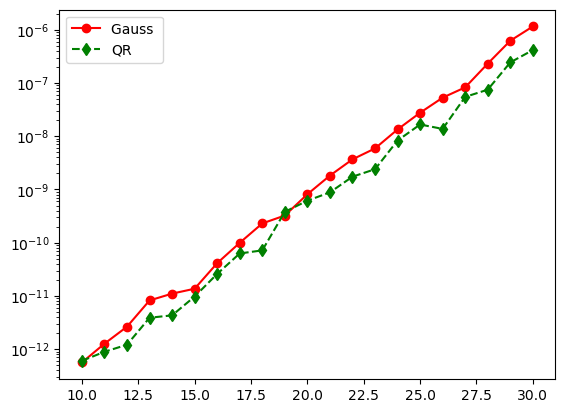

In [20]:
for n in range(10, 31):
    A = Hankel(n)
    b = np.sum(A, axis=1)
    x_esatta = np.ones((n,1))
    PT,L,U = lu(A)
    
    fattore_crescita_U = np.max(np.abs(U)) / np.max(np.abs(A))
    
    P = PT.T
    xLU, flag = LUsolve(P, L, U, b)

    err_rel_sol_lu.append(np.linalg.norm(xLU - x_esatta, 2) / np.linalg.norm(x_esatta, 2))

    indCond.append(np.linalg.cond(A, np.inf))

    Q,R = qr(A)

    fattore_crescita_R = np.max(np.abs(R)) / np.max(np.abs(A))
    
    y = Q.T@b
    x_qr, flag = ST.Usolve(R, y)

    print("Fattore cresciita U", fattore_crescita_U, "Fattore cresciita R", fattore_crescita_R)
    
    err_rel_sol_qr.append(np.linalg.norm(x_qr - x_esatta, 2) / np.linalg.norm(x_esatta, 2))

plt.semilogy(np.arange(10, 31), indCond)
plt.ylabel("Indice di condizionamento")
plt.xlabel("n")
plt.show()
plt.semilogy(np.arange(10, 31), err_rel_sol_lu, 'ro-', np.arange(10, 31), err_rel_sol_qr, 'gd--')
plt.legend(["Gauss ", "QR"])
plt.show()

## Esercizio 8

Ripetere l'esercizio precedente per risolvere il sistema lineare $Ax = b$
con $A$ e $b$ cos\`i  definiti:
$$
a^{(n)}_{i,j}=
\left \{
\begin{array}{ll}
1 & \hbox{se} \ i=j \ \hbox{o \, se} \ j=n,\\
-1 & \hbox{se} \ i>j,\\
0 & \hbox{altrimenti}
\end{array}
\right .
\qquad
b = A \cdot [1, ..., 1]^T,
$$
per $n = 48 : 2 : 58$ e $b$ scelto in modo che risulti $x = [1, 1, ..., 1]^T$. Che
cosa si osserva?